In [1]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn

from datetime import datetime

from matplotlib import pyplot as plt

import matplotlib as mpl

In [2]:
pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)["coarse_label_name"].unique()

array(['aquatic_mammals', 'food_containers', 'small_mammals',
       'large_natural_outdoor_scenes', 'large_carnivores', 'vehicles_1',
       'people', 'flowers', 'medium_mammals', 'reptiles',
       'large_omnivores_and_herbivores', 'fruit_and_vegetables', 'trees',
       'household_furniture', 'vehicles_2', 'fish',
       'household_electrical_devices', 'large_man_made_outdoor_things',
       'insects', 'non_insect_invertebrates'], dtype=object)

In [3]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.1


SELECTED_GROUP = "aquatic_mammals"

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_fine_labels(name):

    if "class" in name:
        label = int(name.replace("class", ""))
        return [label]
    df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[4, 30, 55, 72, 95]

In [6]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(100)).difference(SELECTED_CLASSES))

In [7]:
NOT_SELECTED_CLASSES

[0,
 1,
 2,
 3,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 96,
 97,
 98,
 99]

In [8]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [9]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("cifar100").input_transformation
ds_train = CIFAR100(root="../../datasets", download=False, train=True, transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = CIFAR100(root="../../datasets", download=False, train=False, transform=transform,  target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [10]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/40 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0456


  0%|          | 0/79 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0500


In [11]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        
        
        # max_logit_selected = logits[:, SELECTED_CLASSES].max(dim=1).values
        # max_logit_notselected = logits[:, NOT_SELECTED_CLASSES].max(dim=1).values

        # assert len(max_logit_selected.shape) == 1

        # return max_logit_selected - 0* max_logit_notselected
        
    
def construct_model():
    model = models.get_trained_model("cifar100-resnet18-v1")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 32, 32)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [12]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [13]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/79 [00:00<?, ?it/s]

0.9474074840545654

In [14]:
def extract_logits(model, dl, verbose=False):
    arr_logits = []
    for x, y in tqdm(dl, disable=not verbose, desc="Extract Logits"):
        x = x.to(DEVICE)
        logits = model(x).detach().cpu().numpy()
        arr_logits.extend(logits.tolist())
    return np.array(arr_logits)
    
extract_logits(model, dl_train)

array([-11.6477108 , -13.4329052 , -13.27223778, ...,   6.56196499,
       -15.36748981, -10.1568985 ])

  0%|          | 0/40 [00:00<?, ?it/s]

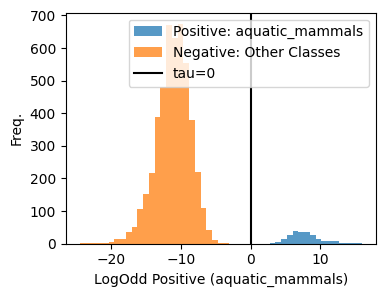

In [15]:
def compute_logit_distribution(model, verbose=False):
    dl =  dl_train

    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        arr_y.extend(y.detach().numpy().tolist())
        arr_logits.extend(logit.detach().numpy().tolist())

    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    plt.figure(figsize=(4, 3))
    vmin, vmax = np.min(arr_logits), np.max(arr_logits)
    bins = np.linspace(vmin, vmax, 50)
    
    plt.hist(
        arr_logits[arr_y == 1],
        bins=bins,
        label=f"Positive: {SELECTED_GROUP}",
        alpha=0.75
    )
    plt.hist(
        arr_logits[arr_y == 0],a
        bins=bins,
        label=f"Negative: Other Classes",
        alpha=0.75
    )
    tau = 0
    plt.axvline(tau, label=f"tau={tau}", color="black")
    plt.ylabel("Freq.")
    plt.xlabel(f"LogOdd Positive ({SELECTED_GROUP})")
    plt.legend()
    
compute_logit_distribution(model, verbose=True)    

# Extract Activation

## Output Quantities

In [48]:
class LogOddWinningClass(attributors.LogitModifier):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits
    def __str__(self):
        return "LogOddWinningClass"

class LogOddWinningClassSign(attributors.LogitModifier):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach()
    def __str__(self):
        return "LogOddWinningClass"

OUTPUT_MODIFIER = LogOddWinningClass()

## Sample Selection Critieria

In [55]:
from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

In [58]:
def extract_activation_context(
    model: nn.Module,
    layer: str,
    dataset: datasets.DatasetConfiguration,
    data_loader: DataLoader,
    logit_modifier: attributors.LogitModifier,
    gamma: int,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
):
    arr_act = []
    arr_ctx = []

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

            
        composite = EpsilonGammaBox(
                low=0, high=1, canonizers=[ResNetCanonizer()], 
                gamma=gamma,
        )
    
        attributor = Gradient(model=model, composite=composite)

        
        with attributor:
            for batch in tqdm(data_loader, desc=f"EpsilonGammaBox(gamma={gamma:.4f})"):
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)

                assert act.grad is not None
                rel = act.grad

                output_dimensions = act.shape[1:]

                ctx = torch.where(act.abs() > 0, rel / act, 0)

                if strict_mode:
                    np.testing.assert_allclose(
                        (act * ctx).detach().cpu().numpy(),
                        rel.detach().cpu().numpy(),
                        atol=1e-6,
                    )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx

In [59]:
class Attributor:
    def __call__(self, model: nn.Module, dl: DataLoader):
        raise


class GradAttributor(Attributor):
    def __call__(self, model, layer, dataloader, device=DEVICE, number_of_selected_spatial_locations=20, seed=1):
        
        arr_act = []
        arr_ctx = []
    
        rng = np.random.default_rng(seed=seed)
    
        try:
            
            module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                model, layer, should_retain_grad=True, detach_output=False
            )
            
            for batch in tqdm(
                dataloader, 
                desc=f"[attributor={self}, layer={layer}] extract actctx  wrt {OUTPUT_MODIFIER} (group={SELECTED_GROUP})"
            ):
                x, y = batch
                x = x.to(device)
    
                logits = model(x)
                
                arr_logodds = OUTPUT_MODIFIER(logits, y)
                
                (arr_logodds).sum().backward()
                act = utils.interceptor.get_output(module)
    
                assert act.grad is not None
                ctx = act.grad
                
                output_dimensions = act.shape[1:]
    
                assert ctx.shape == act.shape
                
                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()
    
    
                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                
    
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)
    
        finally:
            hook.remove()
            model.fc.task_id = None
    
        print(f"{layer}: output-dims={output_dimensions}")
    
        arr_act = np.vstack(arr_act)
        arr_ctx = np.vstack(arr_ctx)
     
        return arr_act, arr_ctx

    def __str__(self,):
        return "grad"
        
class LRPAttributor(Attributor):
    def __init__(self, gamma=0.25):
        self.gamma = gamma
    def __call__(self, model, layer, dataloader, device=DEVICE, number_of_selected_spatial_locations=20, seed=1):
        rng = np.random.default_rng(seed=seed)
        
        return extract_activation_context(
            model=model,
            layer=layer,
            dataset=dataset,
            data_loader=dataloader,
            logit_modifier=OUTPUT_MODIFIER,
            gamma=self.gamma,
            rng=rng,
            device=DEVICE,
            number_of_selected_spatial_locations=20,
            strict_mode=False,
        )

    def __str__(self,):
        return f"lrp-gamma{self.gamma}"
    

def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    attributor: Attributor,
    dataloader=dl_train,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):
    return attributor(
        model=model,
        layer=layer,
        dataloader=dataloader
    )


def ano():



    for lix in range(1):
        layer = f"layer{lix+1}"
        arr_act, arr_ctx = extract_activation_context_for_task(
            model, 
            layer,
            attributor=GradAttributor(),
        )
    
    
        arr_act_2, arr_ctx = extract_activation_context_for_task(
            model, 
            layer,
            attributor=LRPAttributor(),
        )
        np.testing.assert_allclose(
            arr_act,
            arr_act_2,
            atol=1e-2
        )
        print(f"Sanity check: `{layer}` passed!")
        
ano()

[attributor=grad, layer=layer1] extract actctx  wrt LogOddWinningClass (group=aquatic_mammals):   0%|         …

layer1: output-dims=torch.Size([64, 32, 32])


EpsilonGammaBox(gamma=0.2500):   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])
Sanity check: `layer1` passed!


# Construct Basis

In [60]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        N, d = arr_act.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
        
class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDef(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

# Estimate Performance

In [63]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    attributor,
    arr_ks,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
        attributor=attributor
    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                attributor=f"{attributor}",
                layer=layer,
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)
    
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer1", 
    attributor=LRPAttributor(gamma=0.1),
    arr_basis_names=[
        # PCA,
        # GradPCA,     
        PRCAPosDef,
    ],
    arr_ks=[5, 10, 20],
)

EpsilonGammaBox(gamma=0.1000):   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,attributor,layer,k,basis_name,val_auroc
0,aquatic_mammals,lrp-gamma0.1,layer1,5,PRCAPosDef,0.569784
1,aquatic_mammals,lrp-gamma0.1,layer1,10,PRCAPosDef,0.936494
2,aquatic_mammals,lrp-gamma0.1,layer1,20,PRCAPosDef,0.948816


In [64]:
compute_task_aurocs_at_k(
    model, layer="layer1", 
    attributor=LRPAttributor(gamma=0.01),
    arr_basis_names=[
        # PCA,
        # GradPCA,     
        PRCAPosDef,
    ],
    arr_ks=[5, 10, 20],
)

EpsilonGammaBox(gamma=0.0100):   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,attributor,layer,k,basis_name,val_auroc
0,aquatic_mammals,lrp-gamma0.01,layer1,5,PRCAPosDef,0.600488
1,aquatic_mammals,lrp-gamma0.01,layer1,10,PRCAPosDef,0.944505
2,aquatic_mammals,lrp-gamma0.01,layer1,20,PRCAPosDef,0.949049


In [65]:
compute_task_aurocs_at_k(
    model, layer="layer1", 
    attributor=LRPAttributor(gamma=0.0),
    arr_basis_names=[
        # PCA,
        # GradPCA,     
        PRCAPosDef,
    ],
    arr_ks=[5, 10, 20],
)

EpsilonGammaBox(gamma=0.0000):   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,attributor,layer,k,basis_name,val_auroc
0,aquatic_mammals,lrp-gamma0.0,layer1,5,PRCAPosDef,0.762435
1,aquatic_mammals,lrp-gamma0.0,layer1,10,PRCAPosDef,0.945624
2,aquatic_mammals,lrp-gamma0.0,layer1,20,PRCAPosDef,0.947174


## Estimate Statistics

In [66]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [69]:
def estimate_stats(
    arr_basis_names=[
        # PCA,
        # GradPCA,
        PRCAPosDef,
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    for attributor in [
        GradAttributor(),
        LRPAttributor(0.0),
        LRPAttributor(0.01),
        LRPAttributor(0.1),
        LRPAttributor(10)
    ]:
        
        for layer in tqdm(arr_layers, desc=f"{attributor}"):
            d = LAYER_DIM_MAPPING[layer]
            arr_ks = np.linspace(1, 32, 10).astype(int)
    
            df = compute_task_aurocs_at_k(
                model, layer=layer, 
                arr_basis_names=arr_basis_names,
                arr_ks=arr_ks,
                attributor=attributor
            )
            arr_dfs.append(df)

    return pd.concat(arr_dfs)

df_stats_all_samples = estimate_stats()

grad:   0%|          | 0/4 [00:00<?, ?it/s]

[attributor=grad, layer=layer1] extract actctx  wrt LogOddWinningClass (group=aquatic_mammals):   0%|         …

layer1: output-dims=torch.Size([64, 32, 32])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[attributor=grad, layer=layer2] extract actctx  wrt LogOddWinningClass (group=aquatic_mammals):   0%|         …

...

layer3: output-dims=torch.Size([256, 8, 8])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

EpsilonGammaBox(gamma=10.0000):   0%|          | 0/40 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 4, 4])


[          PRCAPosDef] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

In [70]:
df_stats_all_samples

,data_group,attributor,layer,k,basis_name,val_auroc
0,aquatic_mammals,grad,layer1,1,PRCAPosDef,0.500000
1,aquatic_mammals,grad,layer1,4,PRCAPosDef,0.616341
2,aquatic_mammals,grad,layer1,7,PRCAPosDef,0.868021
3,aquatic_mammals,grad,layer1,11,PRCAPosDef,0.948689
4,aquatic_mammals,grad,layer1,14,PRCAPosDef,0.947012
...,...,...,...,...,...,...
5,aquatic_mammals,lrp-gamma10,layer4,18,PRCAPosDef,0.976231
6,aquatic_mammals,lrp-gamma10,layer4,21,PRCAPosDef,0.976700
7,aquatic_mammals,lrp-gamma10,layer4,25,PRCAPosDef,0.977620
8,aquatic_mammals,lrp-gamma10,layer4,28,PRCAPosDef,0.975932


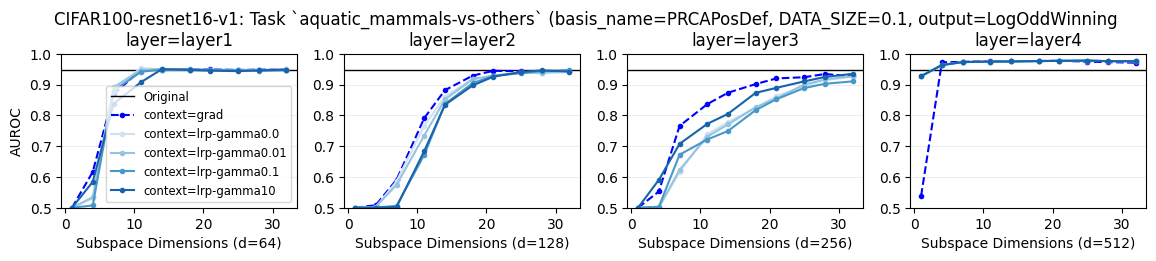

In [87]:
def viz(
    df, 
    basis_name,
    arr_attributors=[
        "grad",
        "lrp-gamma0.0",
        "lrp-gamma0.01",
        "lrp-gamma0.1",
        "lrp-gamma10",
    ],
    
):

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(3.5*ncols, 2))
    plt.suptitle(
        f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (basis_name={basis_name}, DATA_SIZE={DATA_SIZE}, output=LogOddWinning", 
        y=1.1
    )

    cmap = mpl.colormaps["Blues"]
    color_mapping = {
        "grad": "blue",
        "lrp-gamma0.0": cmap(0.2),
        "lrp-gamma0.01": cmap(0.4),
        "lrp-gamma0.1": cmap(0.6),
        "lrp-gamma10": cmap(0.8),
    }
    
    def ls(attr_name):
        if "grad" in attr_name:
            return "--"

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        
        d = LAYER_DIM_MAPPING[layer]

        for six, attributor in enumerate(arr_attributors):
            
            _df = df[
                (df.basis_name == basis_name) \
                    & (df.attributor == attributor) \
                    & (df.layer==layer)
            ]
            
            assert _df.shape[0] > 0
            
            if six == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
                for v in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")


            context_from = attributor.replace("Attributor", "")
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=f"context={context_from}",
                # color="blue",
                color=color_mapping[attributor],
                ls=ls(attributor)
            )

        if lix == 0:
            plt.ylabel("AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats_all_samples,
    basis_name = "PRCAPosDef",    
)

In [ ]:
print(f"Finished at {datetime.now()}")